### Imports

In [1]:
import json
from pathlib import Path

import optuna
import torch
from torch import nn

from src.config import CONFIG
from src.datasets.spike_dataset import SpikeDataset
from src.engine import benchmark_snn, train_one_epoch_snn, validate_snn, get_split_dataloaders
from src.models.snn_1d_encoded_classifier import SNN1DEncodedClassifier
from src.utils import plot_training_history, run_sweep

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
MODEL_NAME = SNN1DEncodedClassifier.NAME

INPUT_DIR = Path('../../processed/audioMNIST')
HYPERPARAMETERS_PATH = Path(f'../../hyperparameters/{MODEL_NAME}.json')
MODEL_PATH = Path(f'../../models/{MODEL_NAME}.pth')

NUM_EPOCHS = 20

### Device

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Hyperparameter Tuning

In [4]:
def objective(trial) -> float:
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    beta = trial.suggest_float('beta_init', 0.5, 0.99)
    slope = trial.suggest_int('slope', 10, 50)

    dataset = SpikeDataset(INPUT_DIR)
    train_dataloader, val_dataloader, _ = get_split_dataloaders(dataset)

    model = SNN1DEncodedClassifier(beta_init=beta, slope=slope).to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    val_acc = 0.0
    for epoch in range(CONFIG.hyperparameter_tuning.epochs):
        train_one_epoch_snn(device, model, criterion, optimiser, train_dataloader, leave=False)
        val_loss, val_acc = validate_snn(device, model, criterion, val_dataloader, leave=False)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_acc

if CONFIG.hyperparameter_tuning.should_run:
    run_sweep(objective, HYPERPARAMETERS_PATH)

### Training

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Features shape: torch.Size([64, 2, 27, 64])
Labels shape: torch.Size([64])

Hyperparameters used: {'lr': 0.008155826180252698, 'beta_init': 0.5845752633099218, 'slope': 10}

Training snn_1d_encoded...
[Epoch 1/20]


Validating:   0%|          | 0/47 [00:00<?, ?batches/s]/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Validating: 100%|██████████| 47/47 [00:04<00:00,  9.59batches/s]


Train Loss: 1.04 | Train Accuracy: 63.22% | Val Loss: 0.52 | Val Accuracy: 80.97%

[Epoch 2/20]


Validating: 100%|██████████| 47/47 [00:01<00:00, 24.70batches/s]


...

Train Loss: 0.15 | Train Accuracy: 94.98% | Val Loss: 0.15 | Val Accuracy: 95.00%

[Epoch 20/20]


Validating: 100%|██████████| 47/47 [00:01<00:00, 23.90batches/s]


Train Loss: 0.15 | Train Accuracy: 95.03% | Val Loss: 0.15 | Val Accuracy: 95.23%

Best model had an accuracy of 95.23%.
Running final test...


Benchmarking: 100%|██████████| 47/47 [00:07<00:00,  6.24batches/s]


Test Accuracy: 95.60% | Average ACs per Inference: 122831


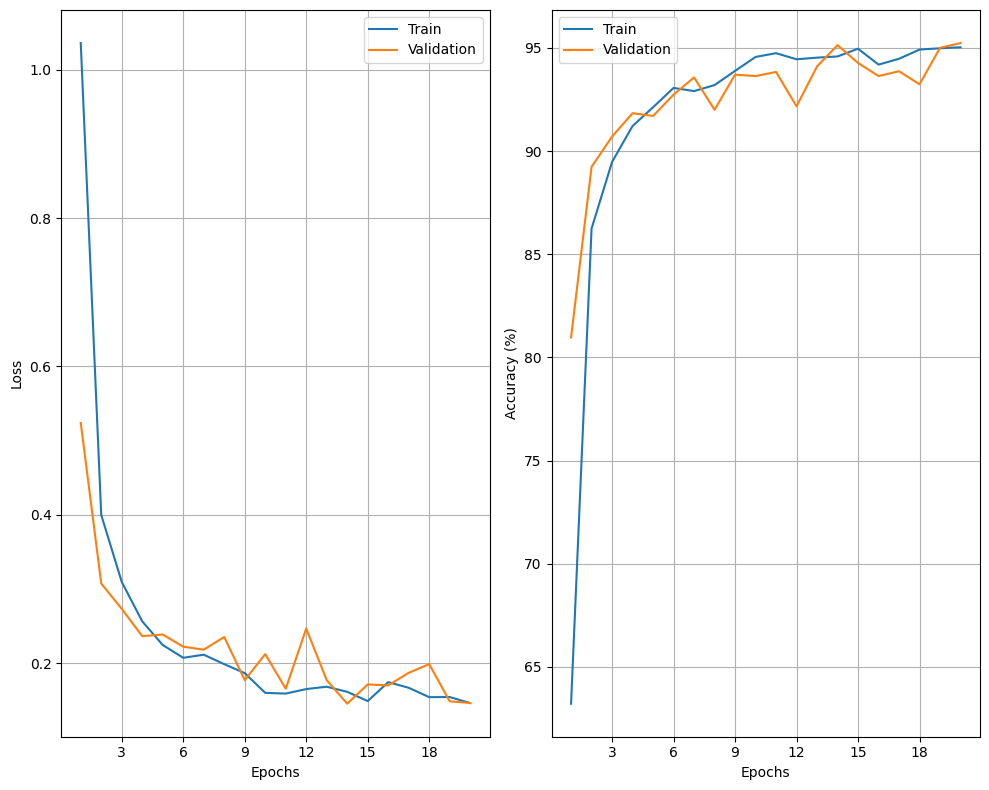

In [5]:
if __name__ == '__main__':
    dataset = SpikeDataset(INPUT_DIR)
    train_dataloader, val_dataloader, test_dataloader = get_split_dataloaders(dataset)

    # Get one batch from the training loader and make sure it looks good
    features, labels = next(iter(train_dataloader))
    print(f'Features shape: {features.shape}')
    print(f'Labels shape: {labels.shape}')
    print()

    # Load hyperparameters
    hyperparameters = json.load(open(HYPERPARAMETERS_PATH, 'r'))
    print(f'Hyperparameters used: {hyperparameters}')
    print()

    model = SNN1DEncodedClassifier(beta_init=hyperparameters['beta_init'], slope=hyperparameters['slope']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=hyperparameters['lr'])
    criterion = nn.CrossEntropyLoss()

    print(f'Training {model.NAME}...')
    best_acc = 0.0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    for epoch in range(NUM_EPOCHS):
        print(f'[Epoch {epoch + 1}/{NUM_EPOCHS}]')
        train_loss, train_acc = train_one_epoch_snn(device, model, criterion, optimizer, train_dataloader)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        val_loss, val_acc = validate_snn(device, model, criterion, val_dataloader)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)

        print(f'Train Loss: {train_loss:.2f} | Train Accuracy: {train_acc:.2f}% | Val Loss: {val_loss:.2f} | Val Accuracy: {val_acc:.2f}%')
        print()

    print(f'Best model had an accuracy of {best_acc:.2f}%.')
    print(f'Running final test...')
    model.load_state_dict(torch.load(MODEL_PATH))

    test_accuracy, avg_acs_per_inference, _ = benchmark_snn(device, model, test_dataloader)
    print(f'Test Accuracy: {test_accuracy:.2f}% | Average ACs per Inference: {avg_acs_per_inference}')

    plot_training_history(train_losses, train_accs, val_losses, val_accs)